In [1]:
import reskit as rk
import numpy as np
import geokit as gk
import pandas as pd

In [2]:
gsa_tif = "/benchtop/shared_data/2023_gears/geography/irradiance/global_solar_atlas_v2.9/World_GHI_GISdata_LTAy_AvgDailyTotals_GlobalSolarAtlas-v2_GEOTIFF/GHI.tif"

In [3]:
# first load the GSA as matrix
mx = gk.raster.extractMatrix(gsa_tif)

In [14]:
# identify the row indices at ca. every 1° latitude step
inds = [np.round(i) for i in np.linspace(0, mx.shape[0]-1, 181)]
inds[:10] # show first 10 only as an example

[0.0, 278.0, 556.0, 833.0, 1111.0, 1389.0, 1667.0, 1944.0, 2222.0, 2500.0]

In [5]:
np.nanmax(mx)

7.51

In [ ]:
# first round mx to yield classes (every 10 W/m2), then filter only yield classes every 100 W/m2
mx_yieldclasses = np.round(mx / 0.1) * 0.1
# mask all non-multiples of 100 (would else be too many placements with very little additional info)
mask = mx_yieldclasses % 0.5 != 0  # cannot be divided by 100
mx_yieldclasses[mask] = np.nan
# last extract all unique yield classes but skip NaN and zero if exists
yieldclasses = sorted([yc for yc in np.unique(mx_yieldclasses) if not yc == 0])
print(len(yieldclasses), "yield classes identified.")

In [15]:
# get several exemplary cells for every yield class in every latitude row
cell_dict = {}
count = 0
# iterate over lat rows and initialize nested dict
for row in inds:
    cell_dict[row] = {}
    
    for yieldclass in yieldclasses:
        # Find all column indices in this row that match the yieldclass
        matching_cols = np.where(mx[int(row)] == yieldclass)[0]
        
        if matching_cols.size > 0:
            # Randomly choose up to 5 indices without replacement
            n = min(5, matching_cols.size)
            selected_cols = np.random.choice(matching_cols, size=n, replace=False)
            cell_dict[row][yieldclass] = selected_cols.tolist()
            count+=len(selected_cols)
        else:
            # skip
            continue
print(count, "locations identified")

3088 locations identified


In [31]:
for k, v in placements_hsat_dict.items():
    print(k, len(v))

plcmtid 2161600
lon 1080800
lat 1080800
yieldclass 1080800
axis_tilt 1080800
gcr 1080800
albedo 1080800


In [36]:
# now generate placements for all these

# initialize a placement dict that will later be converted to pandas dataframe
placements_hsat_dict = {}
# iterate over latitude rows first
_plcmtid=0
for i, row in enumerate(cell_dict.keys()):
    lat = 90 - 180*(row/mx.shape[0]) # starts at bottom
    # then iterate over the yield classes
    for yc, cols in cell_dict[row].items():
        # the columns
        for col in cols:
            lon = -180 + 360*(col/mx.shape[1]) # starts left
            for axis_tilt in [-10, -5, 0, 5, 10]:
                for gcr in [0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1.0]:
                    for albedo in [0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7]:
                        # write all placement vars into the plcmt dict
                        placements_hsat_dict.setdefault("plcmtid", []).append(_plcmtid)
                        placements_hsat_dict.setdefault("lon", []).append(lon)
                        placements_hsat_dict.setdefault("lat", []).append(lat)
                        placements_hsat_dict.setdefault("yieldclass", []).append(yc)
                        placements_hsat_dict.setdefault("axis_tilt", []).append(axis_tilt)
                        placements_hsat_dict.setdefault("gcr", []).append(gcr)
                        placements_hsat_dict.setdefault("albedo", []).append(albedo)
                        # increase placement id
                        _plcmtid += 1

placements_hsat_df = pd.DataFrame.from_dict(placements_hsat_dict)
print(len(placements_hsat_df), "combinations for HSAT.")

# # now do the same again for fixed tilt, slightly different parameters
placements_ft_dict = {}
# # iterate over latitude rows first
_plcmtid=0
for i, row in enumerate(cell_dict.keys()):
    lat = -90 + 180*(row/mx.shape[0]) # starts at bottom
    # then iterate over the yield classes
    for yc, cols in cell_dict[row].items():
        # the columns
        for col in cols:
            lon = -180 + 360*(col/mx.shape[1]) # starts left
            for az in np.arange(0, 360, 45):
                for tlt in list(np.arange(-90,0, 10))+list(np.arange(10,90+10, 10)):
                    for gcr in [0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1.0]:
                        for albedo in [0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7]:
                            # write all placement vars into the plcmt dict
                            placements_ft_dict.setdefault("plcmtid", []).append(_plcmtid)
                            placements_ft_dict.setdefault("lon", []).append(lon)
                            placements_ft_dict.setdefault("lat", []).append(lat)
                            placements_ft_dict.setdefault("yieldclass", []).append(yc)
                            placements_ft_dict.setdefault("module_azimuth", []).append(az)
                            placements_ft_dict.setdefault("module_tilt", []).append(tlt)
                            placements_ft_dict.setdefault("gcr", []).append(gcr)
                            placements_ft_dict.setdefault("albedo", []).append(albedo)
                            # increase placement id
                            _plcmtid += 1

placements_ft_df = pd.DataFrame.from_dict(placements_ft_dict)
print(len(placements_ft_df), "combinations for fixed tilt.")


1080800 combinations for HSAT.
31127040 combinations for fixed tilt.


In [34]:
len(placements_ft_df)

58795520

In [35]:
len(placements_hsat_df)

1080800

In [37]:
placements_ft_df.to_csv("placements_ft.csv")
placements_hsat_df.to_csv("placements_hsat.csv")

In [ ]:
# placements_hsat_df["geom"] = placements_hsat_df.apply(lambda x : gk.geom.point(x.lon, x.lat, srs=4326), axis=1)

In [22]:
agg = placements_hsat_df.groupby("plcmtid").first()
agg["geom"] = agg.apply(lambda x : gk.geom.point(x.lon, x.lat, srs=4326), axis=1)

AxHands(ax=<Axes: >, handles=plcmtid
0                [Line2D(_child0)]
1                [Line2D(_child1)]
2                [Line2D(_child2)]
3                [Line2D(_child3)]
4                [Line2D(_child4)]
                    ...           
1080795    [Line2D(_child1080795)]
1080796    [Line2D(_child1080796)]
1080797    [Line2D(_child1080797)]
1080798    [Line2D(_child1080798)]
1080799    [Line2D(_child1080799)]
Length: 1080800, dtype: object, cbar=<matplotlib.colorbar.Colorbar object at 0x7fd3ee94b100>)

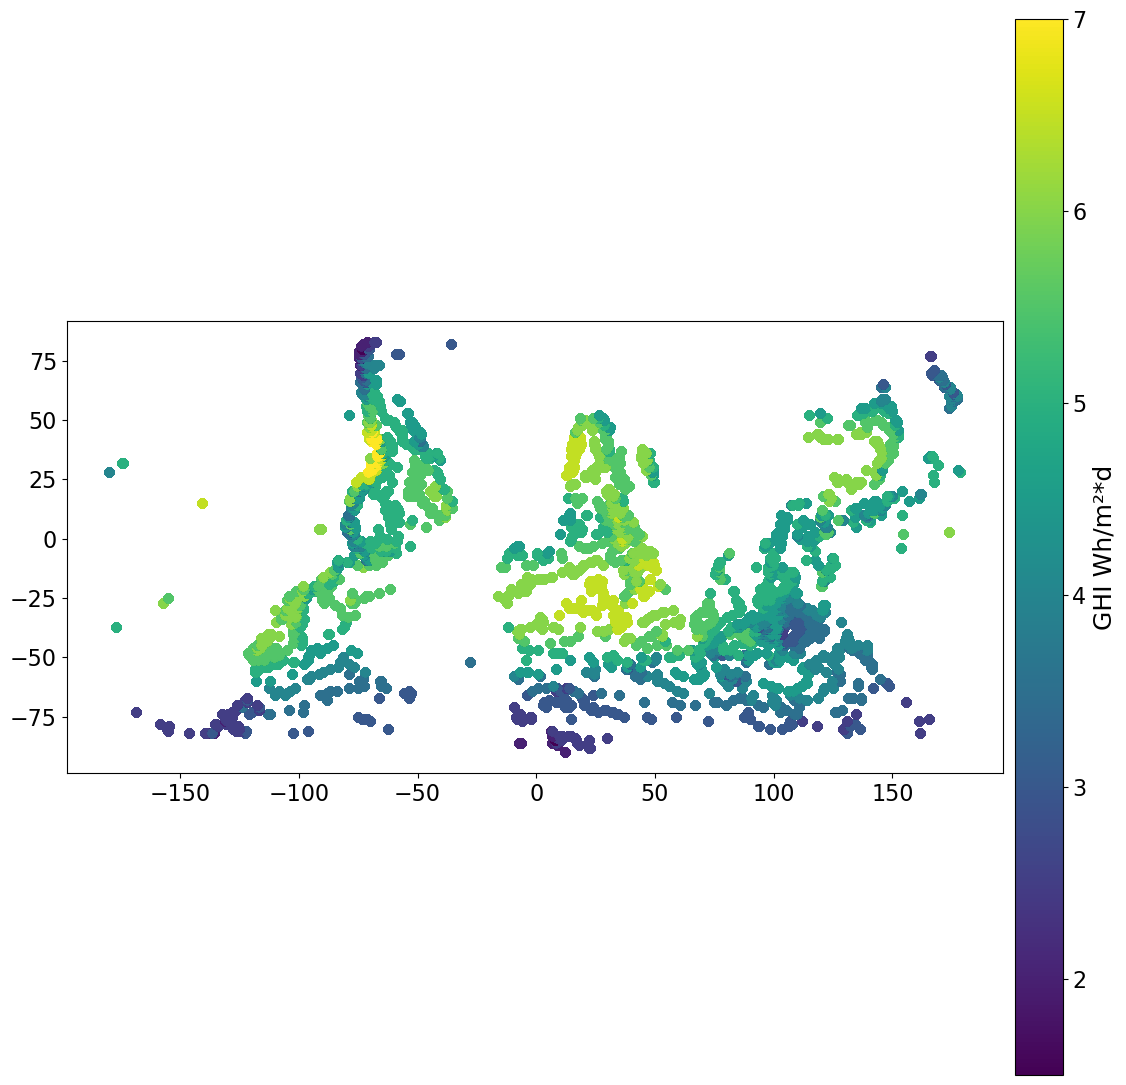

In [26]:
gk.drawGeoms(agg, colorBy="yieldclass", cbarTitle="GHI Wh/m²*d")

In [ ]:
import import reskit as rk
import pandas as pd

# Make a placements dataframe
placements = pd.DataFrame()
placements["lon"] = [
    6.083,
]  # Longitude
placements["lat"] = [
    50.775,
]  # Latitude
placements["tilt"] = [
    32,
]  # System tilt in degrees
placements["azimuth"] = [
    180,
]  # System azimuth in degrees
placements["capacity"] = [
    2000,
]  # Total system capacity in kW
placements["elev"] = [
    250,
]  # Altitute in meters

workflow_args = {
    "placements" : placements,
    "era5_path" : "/benchtop/shared_data/weather_data/processed_weather_data/ERA5_global_processed_V2022.02/4/<X-TILE>/<Y-TILE>/2018/reanalysis-era5-single-levels.z4.x<X-TILE>.y<Y-TILE>.y2018.*.nc",
    "global_solar_atlas_ghi_path" : "/benchtop/shared_data/2023_gears/geography/irradiance/global_solar_atlas_v2.9/World_GHI_GISdata_LTAy_AvgDailyTotals_GlobalSolarAtlas-v2_GEOTIFF/GHI.tif",
    "global_solar_atlas_dni_path" : "/benchtop/shared_data/2023_gears/geography/irradiance/global_solar_atlas_v2.9/World_DNI_GISdata_LTAy_AvgDailyTotals_GlobalSolarAtlas-v2_GEOTIFF/DNI.tif",
    "module" : "LG Electronics LG370Q1C-A5", #"WINAICO WSx-240P6",
    "elev" : 300,
    # "tracking" : "fixed",
    # "tracking_args" : {},
    "tracking": "single_axis",
    "tracking_args": {
        "max_angle": 60
    },
    # "bifaciality_factor" : 0.75,
    "inverter" : None,
    "inverter_kwargs" : {},
    "DNI_nodata_fallback" : 1.0,
    "DNI_nodata_fallback_scaling" : 1.0,
    "GHI_nodata_fallback" : 1.0,
    "GHI_nodata_fallback_scaling" : 1.0,
    "output_netcdf_path" : None,
    "output_variables": None,
    "gsa_nodata_fallback" : "source",
    "albedo" : ("esa_cci_v2.1.1", "/benchtop/shared_data/2023_gears/geography/landcover/esa_cci_v2.1.1/C3S-LC-L4-LCCS-Map-300m-P1Y-2018-v2.1.1.tif"),
    "tech_year" : 2019
    }

out = rk.execute_workflow_iteratively(
    workflow=rk.solar.openfield_pv_era5, weather_path_varname="era5_path", zoom=4, **workflow_args
    )

pass

# out = rk.solar.workflows.openfield_pv_era5(
#     placements = placements,
#     era5_path = "/benchtop/shared_data/weather_data/processed_weather_data/ERA5_global_processed_V2022.02/4/<X-TILE>/<Y-TILE>/2018/reanalysis-era5-single-levels.z4.x<X-TILE>.y<Y-TILE>.y2018.*.nc",
#     global_solar_atlas_ghi_path = "/benchtop/shared_data/2023_gears/geography/irradiance/global_solar_atlas_v2.9/World_GHI_GISdata_LTAy_AvgDailyTotals_GlobalSolarAtlas-v2_GEOTIFF/GHI.tif",
#     global_solar_atlas_dni_path = "/benchtop/shared_data/2023_gears/geography/irradiance/global_solar_atlas_v2.9/World_DNI_GISdata_LTAy_AvgDailyTotals_GlobalSolarAtlas-v2_GEOTIFF/DNI.tif",
#     module="WINAICO WSx-240P6",
#     elev=300,
#     tracking="fixed",
#     inverter=None,
#     inverter_kwargs={},
#     tracking_args={},
#     bifaciality_factor=0.75,
#     DNI_nodata_fallback=1.0,
#     DNI_nodata_fallback_scaling=1.0,
#     GHI_nodata_fallback=1.0,
#     GHI_nodata_fallback_scaling=1.0,
#     output_netcdf_path=None,
#     output_variables=None,
#     gsa_nodata_fallback="source",
#     tech_year=2019
#     )